# Import libs and read data

In [1]:

import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
import os
import pandas as pd

from Strong_hierarchical_lasso.libs_cb_lasso.Helpers_lasso import *




base_path = "../../../KMFM_main_paper/Data/Data_Deoxyfluorination"
filename_Xtrain = "X_train_deoxy.csv"
filename_Xtest = "X_test_deoxy.csv"
filename_ytrain = "y_train_deoxy.csv"
filename_ytest = "y_test_deoxy.csv"

X_train = pd.read_csv(os.path.join(base_path,filename_Xtrain)).to_numpy()
X_test = pd.read_csv(os.path.join(base_path,filename_Xtest)).to_numpy()
y_train = pd.read_csv(os.path.join(base_path,filename_ytrain)).to_numpy().ravel()  
y_test = pd.read_csv(os.path.join(base_path,filename_ytest)).to_numpy().ravel()


#levels
l1, l2, l3= 31, 3, 4 
levels_list=[l1,l2,l3]
X_train_main=X_train[:, range(l1+l2+l3)]
X_test_main=X_test[:, range(l1+l2+l3)]




# RF test set performance 


Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 1}
Train R² = 0.9321, Val R² = 0.7366

Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 2}
Train R² = 0.8366, Val R² = 0.6540

Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1}
Train R² = 0.9382, Val R² = 0.7433

Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2}
Train R² = 0.8627, Val R² = 0.6761

Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features': 0.7, 'min_samples_leaf': 1}
Train R² = 0.9403, Val R² = 0.7477

Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features': 0.7, 'min_samples_leaf': 2}
Train R² = 0.8744, Val R² = 0.6818

Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features': 0.9, 'min_samples_leaf': 1}
Train R² = 0.9498, Val R² = 0.7714

Trying params: {'n_estimators': 50, 'max_depth': 20, 'max_features':

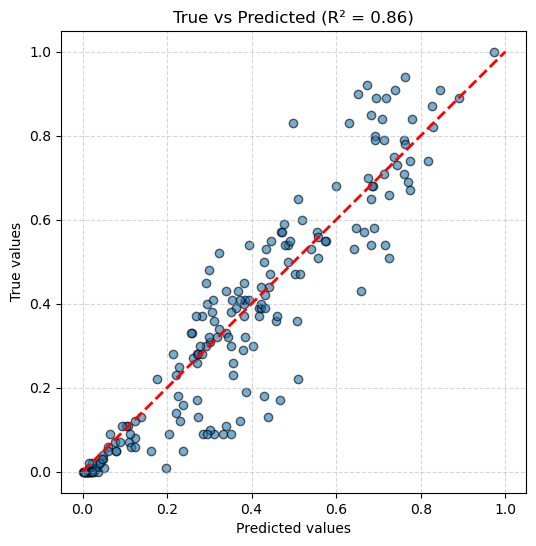

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score as r2, root_mean_squared_error as rmse 
from itertools import product

def grid_search_rf(
    X_train, X_test, y_train, y_test,
    param_grid=None,
    val_size=0.3,
    random_state=42,
    plot=True
):
    """
    Grid search for RandomForestRegressor with an internal validation split.
    Expands all combinations of param_grid values.

    Parameters
    ----------
    param_grid : dict
        Example:
            {
              "n_estimators": [100, 200],
              "max_depth": [5, 10, None],
              "max_features": ["sqrt", 0.5, 1.0],  # like mtry in R
              "min_samples_leaf": [1, 3, 5]        # like nodesize in R
            }

    Returns
    -------
    best_model : fitted RandomForestRegressor
    best_params : dict
    test_r2 : float
    results : list of (params, train_r2, val_r2)
    """

    # --- Split training into (train, validation) ---
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=val_size, random_state=random_state
    )

    # --- Expand param grid (like expand.grid in R) ---
    keys = list(param_grid.keys())
    grid_combinations = [dict(zip(keys, values)) for values in product(*param_grid.values())]

    results = []
    best_val_r2 = -np.inf
    best_params = None
    best_model = None

    # --- Iterate through all combinations ---
    for params in grid_combinations:
        print(f"\nTrying params: {params}")
        model = RandomForestRegressor(random_state=random_state, **params)
        model.fit(X_tr, y_tr)

        y_pred_tr = model.predict(X_tr)
        y_pred_val = model.predict(X_val)

        train_r2 = r2(y_tr, y_pred_tr)
        val_r2 = r2(y_val, y_pred_val)

        results.append((params, train_r2, val_r2))
        print(f"Train R² = {train_r2:.4f}, Val R² = {val_r2:.4f}")

        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            best_params = params
            best_model = model

    # --- Report and retrain ---
    print(f"\nBest parameters: {best_params} (Val R² = {best_val_r2:.4f})")
    best_model = RandomForestRegressor(random_state=random_state, **best_params)
    best_model.fit(X_train, y_train)

    # --- Evaluate on test set ---
    y_pred_test = best_model.predict(X_test)
    test_r2 = r2(y_test, y_pred_test)
    print(f"\nFinal Test R² = {test_r2:.4f}")
    test_rmse=rmse(y_test, y_pred_test)
    print(f"\nFinal Test rmse = {test_rmse:.4f}")

    

    # --- Optional plot ---
    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_pred_test, y_test, alpha=0.6, edgecolors='k')
        min_val = min(y_test.min(), y_pred_test.min())
        max_val = max(y_test.max(), y_pred_test.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        plt.xlabel("Predicted values")
        plt.ylabel("True values")
        plt.title(f"True vs Predicted (R² = {test_r2:.2f})")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    return best_model, best_params, test_r2, results



param_grid = {
    "n_estimators": [50, 200, 500],          
    "max_depth": [ 20, None],          
    "max_features": [ 0.3, 0.5, 0.7,0.9], 
    "min_samples_leaf": [1, 2]        
}

best_model, best_params, test_r2, results = grid_search_rf(
    X_train_main, X_test_main, y_train, y_test,
    param_grid=param_grid,
    val_size=0.3,
    plot=True
)



